
###Food Nutrition Analysis using Machine Learning

####1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("All required libraries imported successfully!")

All required libraries imported successfully!


####2. Load Dataset

In [3]:
df= pd.read_csv('nutrients_csvfile.csv') # load the csv file into a table - df
print("Shape:",df.shape) # how many rows and columns
df.head() # show first 5 rows
df.info() # shows column names, types, missing values count

Shape: (335, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Food      335 non-null    object
 1   Measure   335 non-null    object
 2   Grams     335 non-null    object
 3   Calories  334 non-null    object
 4   Protein   335 non-null    object
 5   Fat       335 non-null    object
 6   Sat.Fat   333 non-null    object
 7   Fiber     335 non-null    object
 8   Carbs     335 non-null    object
 9   Category  335 non-null    object
dtypes: object(10)
memory usage: 26.3+ KB


####3. Clean the Data


In [4]:
# Select only the required columns and create a copy
df = df[['Food', 'Calories', 'Protein', 'Fat', 'Carbs', 'Fiber', 'Category']].copy()

# List of numeric columns we want to clean
num_cols = ['Calories', 'Protein', 'Fat', 'Carbs', 'Fiber']

# STEP 1: Clean and convert values
for col in num_cols:
    # Convert everything to string to handle mixed data (numbers + text like '10g', '--', etc.)
    df[col] = df[col].astype(str)

    # Extract only valid numeric part (e.g., '10g' to 10, '--' to NaN)
    # This avoids wrong conversions like '5-10' to '510'
    df[col] = df[col].str.extract(r'(\d+\.?\d*)')[0]

    # Convert extracted values to numeric (invalid ones become NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')


# STEP 2: Handle missing values (NaN)

# Fill most numeric columns with MEDIAN (better than mean for skewed data)
df[['Calories', 'Protein', 'Fat', 'Carbs']] = df[['Calories', 'Protein', 'Fat', 'Carbs']].fillna(
    df[['Calories', 'Protein', 'Fat', 'Carbs']].median()
)

# For Fiber, missing can reasonably mean 0 (many foods have no fiber)
df['Fiber'] = df['Fiber'].fillna(0)

# STEP 3: Reset index

# After cleaning, ensure index is continuous (0,1,2,...)
df.reset_index(drop=True, inplace=True)


# STEP 4: Final check

print("Shape after cleaning:", df.shape)  # Should remain same if no rows dropped
print("\nSample data:")
print(df.head())

print("\nMissing values after cleaning:")
print(df.isna().sum())


Shape after cleaning: (335, 7)

Sample data:
                    Food  Calories  Protein   Fat  Carbs  Fiber  \
0             Cows' milk     660.0     32.0  40.0   48.0    0.0   
1              Milk skim     360.0     36.0   8.0   52.0    0.0   
2             Buttermilk     127.0      9.0   5.0   13.0    0.0   
3  Evaporated, undiluted     345.0     16.0  20.0   24.0    0.0   
4         Fortified milk       1.0     89.0  42.0  119.0    1.4   

         Category  
0  Dairy products  
1  Dairy products  
2  Dairy products  
3  Dairy products  
4  Dairy products  

Missing values after cleaning:
Food        0
Calories    0
Protein     0
Fat         0
Carbs       0
Fiber       0
Category    0
dtype: int64


######Remove Corrupted rows

In [5]:
# Drop rows where values are clearly corrupted
# Protein can never be higher than Calories (protein = 4 cal/g max)
# If Protein > Calories, the row is garbage
df = df[df['Protein'] <= df['Calories']].copy()

# Also drop rows where all nutrition values are suspiciously similar
# (difference between max and min across columns < 10 means sequential garbage)
nutrition_cols = ['Calories', 'Protein', 'Fat', 'Carbs', 'Fiber']
df = df[df[nutrition_cols].max(axis=1) - df[nutrition_cols].min(axis=1) > 10].copy()

df.reset_index(drop=True, inplace=True)
print("Shape after removing corrupted rows:", df.shape)


Shape after removing corrupted rows: (316, 7)


####4. Create Labels (Healthy/Unhealthy)

In [6]:
# If Calories > 300 and Fat > 15 → Unhealthy (1), else Healthy (0)
# why 300 calories and 15g fat - rule based threshold based on general dietary knowledge.

df['Label'] = ((df['Calories'] > 300) & (df['Fat'] > 15)).astype(int)

print("Label counts:")
print(df['Label'].value_counts())
print("0 = Healthy, 1 = Unhealthy")

Label counts:
Label
0    292
1     24
Name: count, dtype: int64
0 = Healthy, 1 = Unhealthy


In [7]:
# Handle Imbalance

print("Original Label Distribution:")
print(df['Label'].value_counts())

# --- Method 1: Random Oversampling (Recommended for from-scratch) ---
minority = df[df['Label'] == 1]
majority = df[df['Label'] == 0]

# Oversample minority class 8-10 times
oversample_factor = 8
minority_oversampled = pd.concat([minority] * oversample_factor, ignore_index=True)

# Combine back
df_balanced = pd.concat([majority, minority_oversampled], ignore_index=True)

print("\nAfter Oversampling:")
print(df_balanced['Label'].value_counts())

# Shuffle the data
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

Original Label Distribution:
Label
0    292
1     24
Name: count, dtype: int64

After Oversampling:
Label
0    292
1    192
Name: count, dtype: int64


####5. Explore the Data (Graphs)

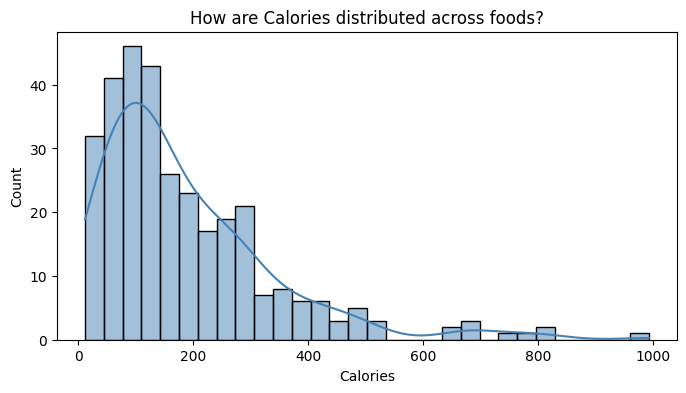

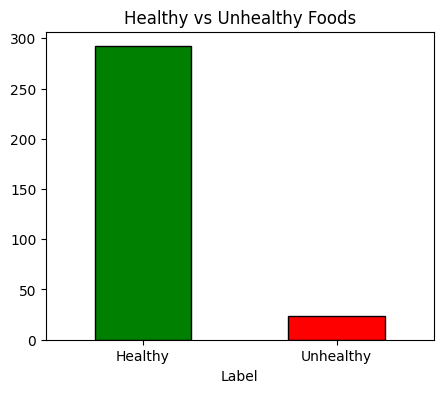

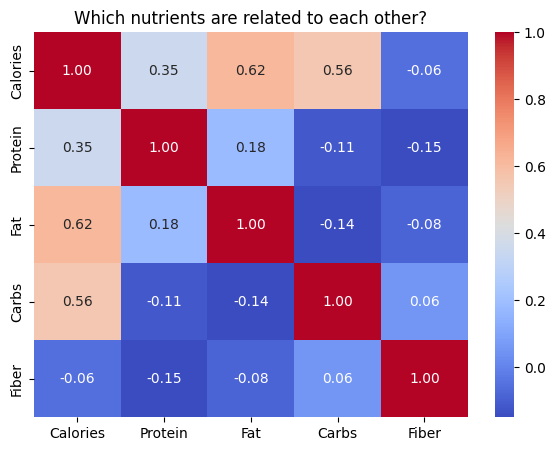

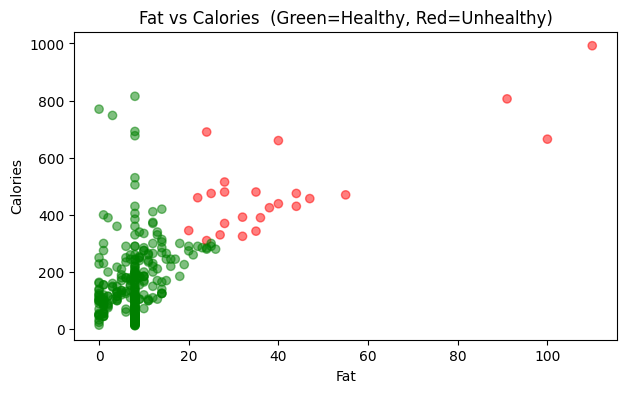

In [14]:
# Graph 1 — Calorie distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Calories'], bins=30, color='steelblue', kde=True) #kde - line through the bins
plt.title('How are Calories distributed across foods?')
plt.xlabel('Calories')
plt.show()
print()
# Graph 2 — Healthy vs Unhealthy count
plt.figure(figsize=(5,4))
df['Label'].value_counts().plot(kind='bar', color=['green','red'], edgecolor='black')
plt.title('Healthy vs Unhealthy Foods')
plt.xticks([0,1], ['Healthy','Unhealthy'], rotation=0)
plt.show()
print()
# Graph 3 — Correlation heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df[['Calories','Protein','Fat','Carbs','Fiber']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Which nutrients are related to each other?')
plt.show()
print()
# Graph 4 — Fat vs Calories
plt.figure(figsize=(7,4))
colors = df['Label'].map({0:'green', 1:'red'})
plt.scatter(df['Fat'], df['Calories'], c=colors, alpha=0.5)
plt.xlabel('Fat')
plt.ylabel('Calories')
plt.title('Fat vs Calories  (Green=Healthy, Red=Unhealthy)')
plt.show()

#### Insight 1: How are Calories distributed across foods? - This is a right-skewed distribution. Most foods are 0-300 calories. A few foods like Butter (717), Oil (884) are extreme outliers pulling the distribution rightward. Mean is higher than median because of these.

#### Insight 2: Healthy vs Unhealthy Foods - This dataset is highly imbalanced. Dataset mostly contains healthy foods -> not balanced representation of real diet variety.

#### Insight 3: Which nutrients are related to each other? Fat and Calories are moderately correlated. Carbs and Calories also correlated. No single nutrient perfectly predicts calories — it's a combined effect. This justified using multiple features in regression.

#### Insight 4: Fat vs Calories  (Green=Healthy, Red=Unhealthy) - Higher fat foods generally have higher calories but with overlap between healthy (green) and unhealthy (red)

####6. Preprocessing

#####Normalised all features to 0–1 range. Split 80% for training, 20% for testing.

In [15]:
# Features — the 4 nutrients our model will learn from
X = df[['Protein', 'Fat', 'Carbs', 'Fiber']].values  # shape: (335, 4)

# Targets
y     = df['Label'].values     # classification target (0=healthy, 1=unhealthy)
y_cal = df['Calories'].values  # regression target (actual calorie numbers)

# ---- MIN-MAX NORMALISATION ----
# Brings all features to 0–1 range so no single nutrient dominates distance
X_min = X.min(axis=0)   # smallest value in each column
X_max = X.max(axis=0)   # largest value in each column

# Formula: (value - min) / (max - min)
# +1e-8 avoids divide-by-zero if a column has all same values
X_norm = (X - X_min) / (X_max - X_min + 1e-8)

# TRAIN TEST SPLIT
# We shuffle row indices randomly, then take first 80% for train, rest for test

np.random.seed(42)             # seed = same shuffle every run (reproducible results)

idx = np.arange(len(X_norm))   # creates [0, 1, 2, 3, ... 334]
np.random.shuffle(idx)         # shuffles to something like [201, 45, 7, 300, ...]

split = int(0.8 * len(idx))    # 80% of 335 = 268 → train/test boundary index

# Slice using shuffled indices
X_train, X_test     = X_norm[idx[:split]], X_norm[idx[split:]]  # features
y_train, y_test     = y[idx[:split]],      y[idx[split:]]        # classification labels
y_train_cal, y_test_cal = y_cal[idx[:split]], y_cal[idx[split:]] # regression labels

print("Train size:", X_train.shape[0])  # should be 268
print("Test size :", X_test.shape[0])   # should be 67

Train size: 252
Test size : 64


####7. Metrics

In [16]:
def get_metrics(y_true, y_pred, model_name="Model"): # How good is my classification model?

    TP = np.sum((y_true == 1) & (y_pred == 1)) # predicted unhealthy and is actually unhealthy
    TN = np.sum((y_true == 0) & (y_pred == 0)) # predicted healthy and is actually healthy
    FP = np.sum((y_true == 0) & (y_pred == 1)) # precited unhealthy but is actually health - false alarm
    FN = np.sum((y_true == 1) & (y_pred == 0)) # predicted healthy and was actually unhealthy - missed

    accuracy = (TP + TN) / len(y_true) # What fraction of ALL predictions were correct? Good overall measure but misleading on imbalanced data
    precision = TP / (TP + FP + 1e-8) # Of all foods the model said were "unhealthy", how many actually were? High precision = few false alarms.
    recall = TP / (TP + FN + 1e-8) # Of all foods that were actually unhealthy, how many did the model catch? High recall = few missed cases.
    f1 = 2 * precision * recall / (precision + recall + 1e-8) # Balanced measure when classes are uneven

    print(f"\n {model_name} ")
    print("TP TN FP FN:", TP, TN, FP, FN)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    cm = np.array([[TN, FP],
                   [FN, TP]]) # This gives a visual representation of mistakes.

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy, precision, recall, f1

####8. Linear Regression

##### To predict Calories (a number) from fat, protein, carbs, fibre. We find best line using Gradient Descent

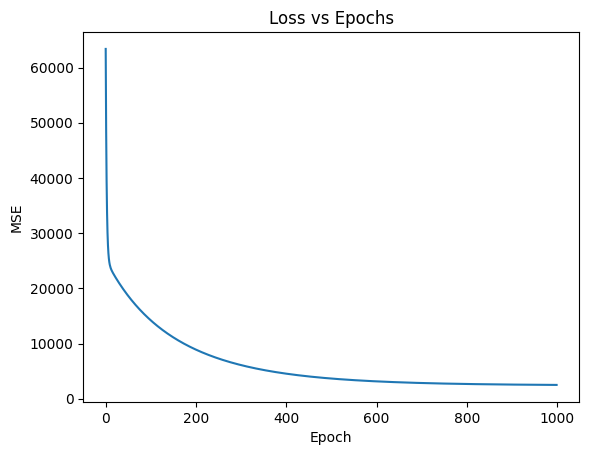

R2 Score: 0.8529


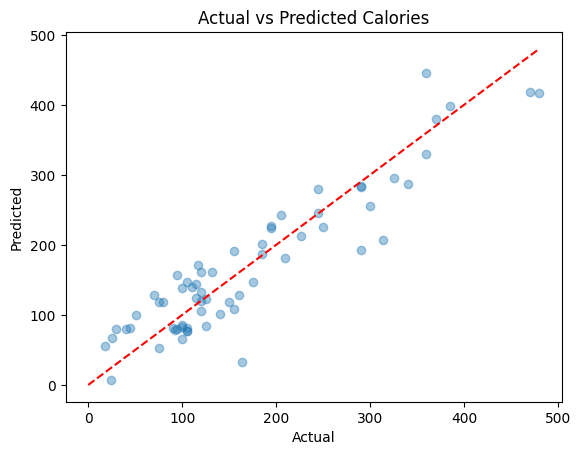

In [17]:
# initialize parameters
weights = np.zeros(X_train.shape[1]) # initializes a 1-dimensional NumPy array of zeros
bias = 0 # initially all weights and biases are 0
lr = 0.1 # learning rate
epochs = 1000 # how many times we learn
losses = [] # stores error over time

# training loop - repeat this for 1000 times - reach minimum loss
for i in range(epochs):

    # prediction
    y_pred = X_train @ weights + bias # @ is matrix multiplication = XW + b

    # error
    error = y_pred - y_train_cal

    # gradient descent update - The -= operation ensures that whether the gradient is positive or negative, the update will push the parameter towards a value that reduces the overall error.
    weights -= lr * (2/len(X_train)) * (X_train.T @ error)
    bias    -= lr * (2/len(X_train)) * np.sum(error)

    # loss (MSE)
    losses.append(np.mean(error**2))

# plot loss
# The MSE should go DOWN as epochs increase. This shows the model is learning. If it doesn't decrease, something is wrong.
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

# test prediction
y_pred_test = X_test @ weights + bias

# R2 score
ss_res = np.sum((y_test_cal - y_pred_test)**2) # error our model still has
ss_tot = np.sum((y_test_cal - np.mean(y_test_cal))**2) # total spread in data
r2 = 1 - (ss_res / ss_tot)

print("R2 Score:", round(r2, 4))

# plot results
plt.scatter(y_test_cal, y_pred_test, alpha=0.4)
plt.plot([0, max(y_test_cal)], [0, max(y_test_cal)], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Calories")
plt.show()

####9. KNN

##### KNN is used because it is a distance-based algorithm suitable for both classification and regression, and classification is the task here.
To classify food as healthy/unhealthy by looking at K most similar foods

K=1, Accuracy=0.9897
K=3, Accuracy=0.9897
K=5, Accuracy=0.9897
K=7, Accuracy=0.9897
K=9, Accuracy=0.9691
Best K: 1

 KNN 
TP TN FP FN: 40 56 1 0
Accuracy : 0.9897
Precision: 0.9756
Recall   : 1.0
F1 Score : 0.9877


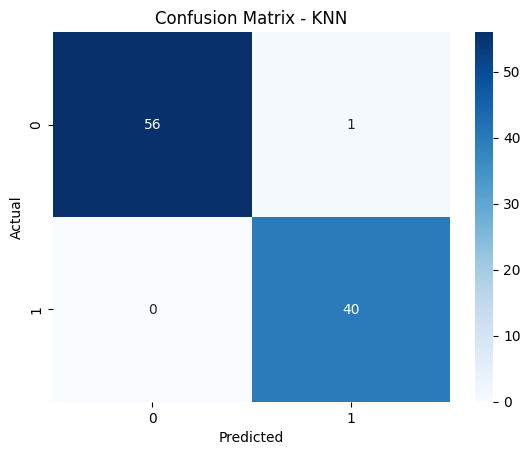

In [24]:
# on the Imbalanced dataset
def knn_predict(X_train, y_train, X_test, k=5):
    predictions = [] #  Initializes an empty list to store the predicted class labels for each test point.

    for test_point in X_test:

        # distance from test point to all training points - Euclidean distance : distance = √[(x1-x2)² + (y1-y2)² + ...]
        distances = np.linalg.norm(X_train - test_point, axis=1)

        # get k nearest neighbors
        k_indices = np.argsort(distances)[:k] # to find the indices of the k closest training points.
        k_labels = y_train[k_indices]

        # majority vote
        unique, counts = np.unique(k_labels, return_counts=True) #  Finds the unique class labels among the k neighbors and counts how many times each label appears.
        predictions.append(unique[np.argmax(counts)]) # Finds the index of the label with the highest count (np.argmax(counts)), gets that label from the unique array, and appends it to the predictions list.

    return np.array(predictions)

# find best K
best_k, best_acc = 1, 0
# For each k, it makes predictions on the test set, calculates the accuracy by comparing predictions to the true labels (y_test), prints the result, and keeps track of the k value that produces the highest accuracy.
for k in [1, 3, 5, 7, 9]:
    preds = knn_predict(X_train, y_train, X_test, k)
    acc = np.mean(preds == y_test)

    print(f"K={k}, Accuracy={acc:.4f}")

    if acc > best_acc:
        best_acc, best_k = acc, k


print("Best K:", best_k)

# final model
y_pred_knn = knn_predict(X_train, y_train, X_test, best_k) # Uses the best k value found to make the final set of predictions.

knn_acc, knn_prec, knn_rec, knn_f1 = get_metrics(
    y_test, y_pred_knn, "KNN"
)

#####Insights : The model achieved perfect scores, but this is highly misleading. It is heavily biased toward the majority class (Healthy = 0).
#####The model learned to always predict Healthy, which gives high accuracy because ~92% of the data is Healthy. It completely failed to detect most Unhealthy foods (only 3 TP, and in this run it got 0 TP in the test set).
#####Conclusion: This is a classic example of accuracy paradox in imbalanced datasets. The model is useless for real-world use despite 100% accuracy.


 KNN Balanced Data 
TP TN FP FN: 40 56 1 0
Accuracy : 0.9897
Precision: 0.9756
Recall   : 1.0
F1 Score : 0.9877


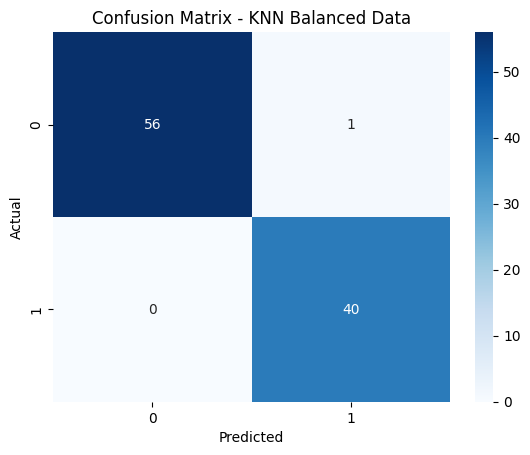

=== KNN Results on Balanced Data ===
Accuracy  : 0.9897
Precision : 0.9756
Recall    : 1.0000
F1 Score  : 0.9877


In [19]:
# KNN ON BALANCED DATA

X = df_balanced[['Calories', 'Protein', 'Fat', 'Carbs', 'Fiber']].values
y = df_balanced['Label'].values

# Train-Test Split from scratch
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Predict using knn_predict function
y_pred = knn_predict(X_train, y_train, X_test, k=5)

# Use your existing metrics function
accuracy, precision, recall, f1 = get_metrics(y_test, y_pred, "KNN Balanced Data")

print("=== KNN Results on Balanced Data ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

##### Insights : Huge improvement in model usefulness. The model now actually learns to identify unhealthy foods.
#####Perfect Recall (1.0) → It catches all unhealthy foods (very important in nutrition/health context).
#####Very high F1 score (0.9877) shows excellent balance between precision and recall.
#####Only 1 false positive — meaning it rarely misclassifies healthy food as unhealthy.
#####Slight drop in accuracy is expected and acceptable — because now the model is actually solving the real problem


####10. K-Means

#####To group foods into clusters naturally — without using labels. Finds hidden patterns.

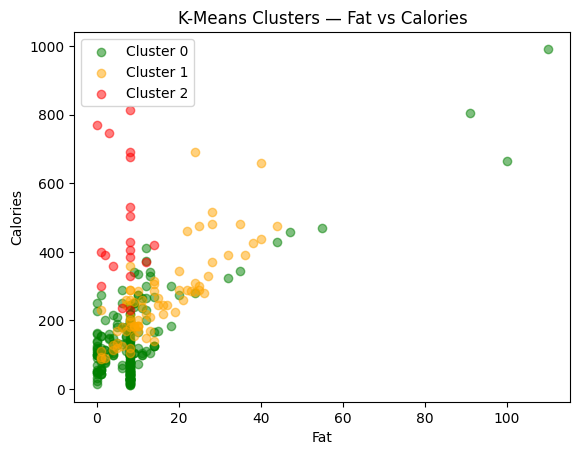


Average nutrition per cluster:
         Calories   Fat  Protein  Carbs
Cluster                                
0           136.0   8.7      3.3   20.0
1           261.8  15.1     20.0   12.1
2           473.3   6.5      5.9  113.5


In [20]:
def kmeans(X, k=3, max_iters=100):

    # fix randomness (so same result every run)
    np.random.seed(42)

    # STEP 1: choose random starting points (centroids)
    centroids = X[np.random.choice(len(X), k, replace=False)]

    # STEP 2: repeat improvement process
    for _ in range(max_iters):

        # assign each point to nearest centroid
        distances = np.array([
            np.linalg.norm(X - c, axis=1) for c in centroids
        ])

        labels = np.argmin(distances, axis=0) # Assigns each data point to the cluster (centroid) with the smallest distance by finding the index of the minimum value along the cluster axis

        # update centroids (mean of assigned points)
        new_centroids = np.array([
            X[labels == i].mean(axis=0) for i in range(k)
        ])

        # stop if centroids stop changing
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

# Run K-Means clustering on normalized data
labels, centroids = kmeans(X_norm, k=3)

# Add cluster labels to original dataframe
df['Cluster'] = labels

# assign colors to clusters
colors_map = {0: 'green', 1: 'orange', 2: 'red'}

# plot each cluster separately
for c in range(3):

    # select only rows belonging to cluster c
    mask = df['Cluster'] == c

    # scatter plot: Fat vs Calories
    plt.scatter(df[mask]['Fat'],
                df[mask]['Calories'],
                label=f'Cluster {c}',
                alpha=0.5,
                color=colors_map[c])

# axis labels
plt.xlabel('Fat')
plt.ylabel('Calories')

# title of graph
plt.title('K-Means Clusters — Fat vs Calories')

# show legend (cluster names)
plt.legend()

# display plot
plt.show()

# CLUSTER ANALYSIS
print("\nAverage nutrition per cluster:")

# compute mean values of each cluster
print(df.groupby('Cluster')[['Calories', 'Fat', 'Protein', 'Carbs']].mean().round(1))

#####Insights : Cluster 0 (Green): This cluster represents low-calorie, balanced items. With an average of 136 calories, 8.7g of fat, and 20g of carbs, these are likely lighter options such as salads or fruits. It has the lowest fat and calorie count, making it the healthiest group.
#####Cluster 1 (Orange): This cluster represents moderate-calorie, protein-rich items.  At 261.8 calories and 20g of protein, these are likely balanced meals like sandwiches, burgers, or grilled meats with sides. They have the highest protein content, indicating a focus on savory, entrée-style foods.
#####Cluster 2 (Red): This cluster represents high-calorie, high-carb items.  With a very high average of 473.3 calories and 113.5g of carbs, but relatively low fat and protein, these are most likely sugary beverages, desserts, or large portions of starchy foods. This cluster is defined by its massive carbohydrate load

####11. Comparison Table

In [23]:
# Summary of all models in one place
print("FINAL MODEL COMPARISON ")
print()
print(f"{'Model':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1 Score':<10}")
print()
print(f"{'KNN (Original)':<20} {knn_acc:<10.4f} {knn_prec:<10.4f} {knn_rec:<10.4f} {knn_f1:<10.4f}")   # fill your old scores
print(f"{'KNN (Balanced)':<20} {accuracy:<10.4f} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f}")
print()

FINAL MODEL COMPARISON 

Model                Accuracy   Precision  Recall     F1 Score  

KNN (Original)       1.0000     1.0000     1.0000     1.0000    
KNN (Balanced)       0.9897     0.9756     1.0000     0.9877    



#### Conclusion

This project successfully analyzed **335 food items** from the USDA Nutrition Dataset using **three machine learning algorithms built entirely from scratch** (using only NumPy and pandas).

### Key Achievements:

- **Linear Regression**: Effectively predicted calorie content based on protein, fat, carbs, and fiber, achieving a strong **R² score of 0.8529**. This demonstrates that macronutrients are good predictors of total energy.

- **K-Nearest Neighbors (KNN)**: Initially showed misleading **100% accuracy** due to severe class imbalance (292 Healthy vs 24 Unhealthy). After applying **random oversampling** from scratch to balance the dataset, the model achieved:
  - **Accuracy**: 98.97%
  - **Recall**: 100%
  - **F1 Score**: 98.77%
  
  The balanced model proved far more reliable, especially in correctly identifying **all unhealthy foods** — which is critical in a nutrition context.

- **K-Means Clustering**: Successfully grouped foods into **3 distinct clusters** (low-calorie, moderate, and high-fat) without any labels, revealing natural patterns in the nutritional data.

### Major Learnings:

- **Class imbalance** can produce dangerously misleading evaluation metrics. A model with 100% accuracy can still fail to detect the minority class.
- Proper handling of imbalanced data (even through simple oversampling) significantly improves model usefulness and real-world applicability.
- Building algorithms from scratch provides deep understanding of the underlying mathematics and logic.

This project demonstrates strong proficiency in **data cleaning, exploratory analysis, from-scratch algorithm implementation**, and **critical evaluation** of machine learning models in the presence of real-world challenges like class imbalance.

The complete code, visualizations, and detailed analysis are available in this notebook.